# דוגמה מסכמת: קינטיקה מסדר ראשון

במחברת זו נשתמש ב־Matplotlib כדי לצייר גרפים של בעיה פשוטה בקינטיקה כימית. נבחן תגובה מסדר ראשון:

$$
A \rightarrow \mathrm{products}
$$

עבור תגובה מסדר ראשון, קצב השינוי של ריכוז המגיב $A$ הוא

$$
\frac{d[A]}{dt} = -k[A].
$$

הפתרון הוא

$$
[A](t) = [A]_0 e^{-kt}.
$$

המטרה שלנו היא לא רק לצייר את הפונקציה, אלא לבנות בהדרגה איור ברור ושימושי לדו״ח מעבדה או למצגת.

## מטרות השיעור

בסוף המחברת נרצה לדעת כיצד:

1. לצייר ריכוז כפונקציה של זמן.
2. להוסיף תוויות צירים עם יחידות.
3. להשתמש בפונקציה כדי להימנע מחזרה מיותרת על קוד.
4. להשוות כמה ערכים של קבוע הקצב $k$.
5. להשתמש בגרף חצי־לוגריתמי כדי לזהות קינטיקה מסדר ראשון.
6. לשמור איור לקובץ.

In [3]:
import numpy as np
import matplotlib.pyplot as plt


## פונקציה עבור ריכוז בתגובה מסדר ראשון

נגדיר פונקציה שמחשבת את הריכוז בזמן $t$. הפונקציה תקבל שלושה פרמטרים:
- `t`: זמן.
- `A0`: הריכוז ההתחלתי, $[A]_0$.
- `k`: קבוע הקצב.

In [4]:
def concentration_first_order(t, A0, k):
    """Return the concentration [A](t) for a first-order reaction.

    Parameters
    ----------
    t : float or array
        Time.
    A0 : float
        Initial concentration.
    k : float
        First-order rate constant.
    """
    return A0 * np.exp(-k * t)


## דעיכה יחידה

נתחיל מתגובה אחת עם הערכים הבאים:

$$
[A]_0 = 1.0\ \mathrm{mol\,L^{-1}},
\qquad
k = 0.25\ \mathrm{min^{-1}}.
$$

נחשב את הריכוז בין $t=0$ לבין $t=20$ דקות.

In [6]:
A0 = 1.0      # mol/L
k = 0.25      # 1/min

t = np.linspace(0, 20, 200)  # min
A = concentration_first_order(t, A0, k)

כעת נצייר את הריכוז כפונקציה של הזמן.

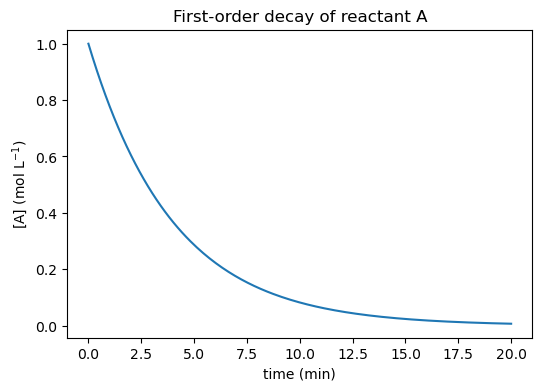

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(t, A)

ax.set_xlabel("time (min)")
ax.set_ylabel("[A] (mol L$^{-1})$")
ax.set_title("First-order decay of reactant A")

plt.show()

הגרף מראה דעיכה אקספוננציאלית: בהתחלה הריכוז יורד מהר, ובהמשך הירידה נעשית איטית יותר. הסיבה לכך היא שהקצב פרופורציוני לריכוז עצמו. כאשר נשאר פחות מהמגיב $A$, גם קצב התגובה קטן.

## גרף חצי־לוגריתמי

עבור תגובה מסדר ראשון,
$$
[A](t) = [A]_0 e^{-kt}.
$$

אם לוקחים לוגריתם טבעי, מקבלים
$$
\ln [A](t) = \ln [A]_0 - kt.
$$

כלומר, אם נצייר את $[A]$ בציר $y$ לוגריתמי ואת הזמן $t$ בציר $x$ רגיל, נקבל קו ישר. זהו גרף חצי־לוגריתמי: רק ציר אחד הוא לוגריתמי.

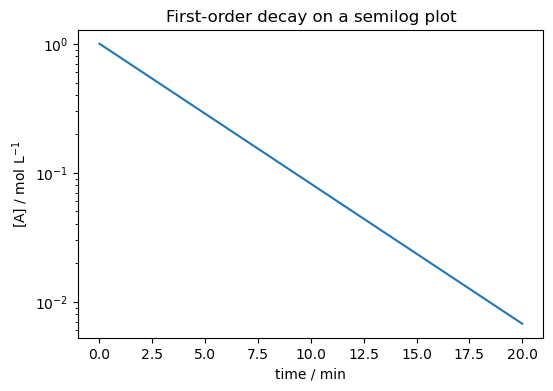

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.semilogy(t, A)

ax.set_xlabel("time / min")
ax.set_ylabel("[A] / mol L$^{-1}$")
ax.set_title("First-order decay on a semilog plot")

plt.show()


בגרף החצי־לוגריתמי, הדעיכה מסדר ראשון נראית כקו ישר. השיפוע של הקו קשור לקבוע הקצב: ככל שהקו יורד מהר יותר, כך $k$ גדול יותר.

## השוואת כמה קבועי קצב

כעת נשווה כמה תגובות מסדר ראשון עם קבועי קצב שונים. אפשר לחשוב על כך כעל אותה תגובה בתנאים שונים, למשל בטמפרטורות שונות או עם זרזים שונים.

In [14]:
A0 = 1.0
t = np.linspace(0, 20, 200)

rate_constants = [0.10, 0.20, 0.40, 0.80]  # 1/min


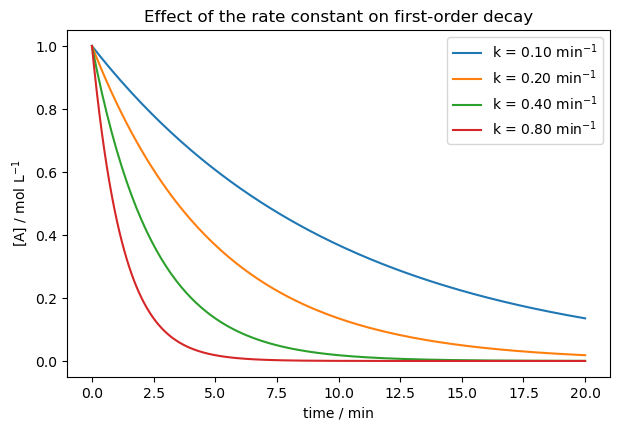

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for k in rate_constants:
    A = concentration_first_order(t, A0, k)
    ax.plot(t, A, label=f"k = {k:.2f} min$^{{-1}}$")

ax.set_xlabel("time / min")
ax.set_ylabel("[A] / mol L$^{-1}$")
ax.set_title("Effect of the rate constant on first-order decay")
ax.legend()

plt.show()


ככל שקבוע הקצב גדול יותר, הריכוז יורד מהר יותר. המקרא (`legend`) מאפשר לנו לראות איזו עקומה מתאימה לאיזה ערך של $k$.

נחזור על אותו ציור, אבל הפעם בגרף חצי־לוגריתמי.

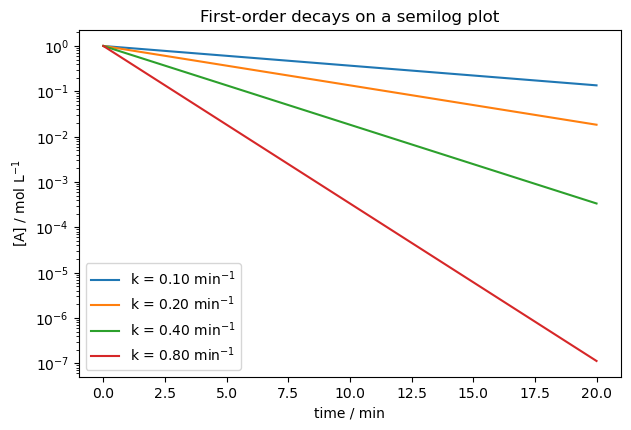

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for k in rate_constants:
    A = concentration_first_order(t, A0, k)
    ax.semilogy(t, A, label=f"k = {k:.2f} min$^{{-1}}$")

ax.set_xlabel("time / min")
ax.set_ylabel("[A] / mol L$^{-1}$")
ax.set_title("First-order decays on a semilog plot")
ax.legend()

plt.show()


בגרף החצי־לוגריתמי, כל העקומות הן קווים ישרים. כאשר $k$ גדול יותר, השיפוע של הקו שלילי יותר.

## שיפור האיור

איור מדעי טוב צריך להיות קריא גם בלי הרבה הסברים מסביב. נשפר את האיור בעזרת:

- גודל איור מתאים לדפוס.
- תוויות צירים עם יחידות.
- כותרת קצרה.
- מקרא.
- קווי־רשת עדינים.
- קווים עבים מעט יותר עבור המידע.
- שמירה לקובץ.

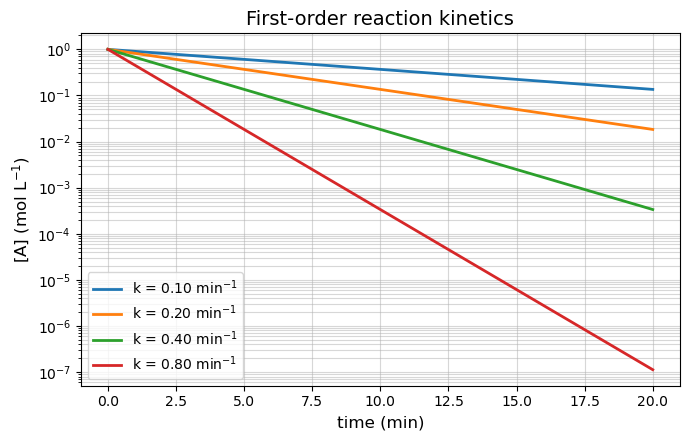

In [27]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for k in rate_constants:
    A = concentration_first_order(t, A0, k)
    ax.semilogy(t, A, linewidth=2, label=f"k = {k:.2f} min$^{{-1}}$")

ax.set_xlabel("time (min)", fontsize=12)
ax.set_ylabel("[A] (mol L$^{-1})$", fontsize=12)
ax.set_title("First-order reaction kinetics", fontsize=14)

ax.legend()
ax.grid(True, which="both", alpha=0.5) # Add a grid, but make it 50% transparent.

fig.tight_layout()
fig.savefig("first_order_kinetics.pdf")

plt.show()

הפקודה
```python
fig.savefig("first_order_kinetics.pdf")
```
שומרת את האיור לקובץ pdf, פורמט המתאים לשימוש בדפוס ובדו"חות. למאמר מקצועי, יש בדרך כלל צורך בהתאמות נוספות. אם רוצים לשים איור באתר אינטרנט או במצגת, אפשר גם לשמור תמונה:
```python
fig.savefig("first_order_kinetics.pdf", dpi=300)
```
האפשרות `dpi=300` יוצרת תמונה ברזולוציה גבוהה יחסית. הרזולוציה תהיה תלויה גם בגודל התמונה שנבחר: כאן 7 על 4.5 אינץ'. היחידות הסטנדרטיות במקרה זה הן אמריקאיות מסיבות היסטוריות.

In [28]:
import json
from jupyterquiz import display_quiz

quiz_json = \
'''
[
  {
    "question": "אם ברצוננו להציג נתונים על פני שלושה סדרי גודל בציר x, הבחירה הטובה היא:",
    "type": "many_choice",
    "answers": [
      {
        "answer": "<code>ax.set_xscale('linear')</code>",
        "correct": false,
        "feedback": "לא נכון — סולם ליניארי לא מתאים לפריסה על פני סדרי גודל רבים."
      },
      {
        "answer": "<code>ax.set_xscale('log')</code>",
        "correct": true,
        "feedback": "נכון! סולם לוגריתמי בציר x מציג היטב נתונים על פני כמה סדרי גודל."
      },
      {
        "answer": "<code>ax.set_yscale('log')</code>",
        "correct": false,
        "feedback": "זה משנה את סולם ציר ה-y, לא את ציר ה-x."
      },
      {
        "answer": "להשאיר ברירת מחדל",
        "correct": false,
        "feedback": "ברירת המחדל היא סולם ליניארי, שאינו מתאים כאן."
      }
    ]
  },
  {
    "question": "איך נקבל את אובייקט הצירים?",
    "type": "many_choice",
    "answers": [
      {
        "answer": "<code>fig = plt.figure()</code>",
        "correct": false,
        "feedback": "זה יוצר Figure בלבד, ללא Axes ברירת מחדל."
      },
      {
        "answer": "<code>ax = plt.axes()</code>",
        "correct": false,
        "feedback": "אמנם יוצר Axes, אך השיטה המומלצת והנפוצה היא <code>plt.subplots()</code>."
      },
      {
        "answer": "<code>fig, ax = plt.subplots()</code>",
        "correct": true,
        "feedback": "נכון! זו הדרך המומלצת: מקבלים גם Figure וגם Axes מוכנים לשימוש."
      },
      {
        "answer": "<code>plt.plot(...)</code>",
        "correct": false,
        "feedback": "זו קריאה בסגנון pyplot; לא יוצרת במפורש אובייקטי Figure ו-Axes לעבודה מבוססת-אובייקטים."
      }
    ]
  },
  {
    "question": "להצגת שדה דו־ממדי (כמו טמפרטורה על רשת), מה מתאים?",
    "type": "many_choice",
    "answers": [
      {
        "answer": "<code>plot</code>",
        "correct": false,
        "feedback": "plot מתאים לעקומות/קווים, לא לשדות דו־ממדיים."
      },
      {
        "answer": "<code>scatter</code>",
        "correct": false,
        "feedback": "scatter מציג נקודות בדידות; לשדה רציף עדיפה הדמיה רסטרית."
      },
      {
        "answer": "<code>hist</code>",
        "correct": false,
        "feedback": "hist מציג התפלגות חד־ממדית (היסטוגרמה), לא מפה דו־ממדית."
      },
      {
        "answer": "<code>imshow</code>",
        "correct": true,
        "feedback": "נכון! imshow (או matshow) מתאימים להצגת שדות/מפות חום דו־ממדיות."
      }
    ]
  }
]
'''
myquiz = json.loads(quiz_json)
display_quiz(myquiz)

ModuleNotFoundError: No module named 'jupyterquiz'